# Asian Option Example

Author: Fred J. Hickernell + ChatGPT

#### Some LaTeX macros (hidden in math mode, will not render correctly in VS Code)
$
\newcommand{\vh}{\boldsymbol{h}}
\newcommand{\vt}{\boldsymbol{t}}
\newcommand{\vx}{\boldsymbol{x}}
\newcommand{\vz}{\boldsymbol{z}}
\newcommand{\vX}{\boldsymbol{X}}
\newcommand{\vU}{\boldsymbol{U}}
\newcommand{\vzero}{\boldsymbol{0}}
\newcommand{\cf}{\mathcal{F}}
\newcommand{\cn}{\mathcal{N}}
\newcommand{\cu}{\mathcal{U}}
\newcommand{\cgp}{\mathcal{G}\!\mathcal{P}}
\newcommand{\dif}{\mathrm{d}}
\newcommand{\Ex}{\mathbb{E}}
\newcommand{\Prob}{\mathbb{P}}
\newcommand{\bbone}{\mathbb{1}}
\newcommand{\reals}{\mathbb{R}}
\newcommand{\disc}{\operatorname{disc}}
\newcommand{\norm}[2]{{\left \lVert #1 \right \rVert}_{#2}}
$

#### Run this notebook in Juypter with the `conda qmcpy` environment or [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/MATH565Fall2025/blob/main/notebooks/KeisterExample.ipynb?flush_cache=true)

In [1]:
# Colab-only setup
if "google.colab" in str(get_ipython()):
    !apt-get -y install cm-super dvipng texlive-latex-extra texlive-latex-recommended
    !pip install git+https://github.com/QMCSoftware/QMCSoftware.git@develop

### Import needed packages and initialize some parameters

In [3]:
import sys
import time
from pathlib import Path
import numpy as np
from scipy import stats
import qmcpy as qp
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
REPO_ROOT = Path.cwd().resolve().parent  # Ensure repo root is on sys.path (for local 'classlib' and 'nbviz')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
from classlib.options.asian import bm_transform, asian_arith_mean_call_payoff, price, price_rqmc
from classlib.plots import plot_middle_half_sample_mean, plot_multiple_middle_half_sample_means
import classlib.nbviz as nb
nb.init(use_tex=True)     # styling, Tol cycle, CSS
colors, TINY = nb.TOL_BRIGHT, nb.TINY

## Asian Arithmetic Mean Option
Brownian motions are used in financial modeling.  If 
- $S_0$ is the initial price of a stock/asset
- $r$ is the interest rate
- $\sigma$ is the volatility
Then
$$
S(t) = S_0 \exp\bigl((r -\sigma^2/2)t  + \sigma B(t) \bigr)
$$
is a _geometric Brownian motion_ model of the stock price.

The payoff of an Asian Arithmetic Mean call option is
$$ 
\max\left(\frac 1T \int_0^T S(t) \mathrm{d} t - K, 0 \right) \exp(-rT)
$$ 
where $T$ is the time to maturity and $K$ is the strike price.  We can approximate this integral by the trapezoidal rule.

Below is a function that computes an discounted option payoff for an Asian arithmetic mean call.

In [8]:
# Asian Option Parameters
T=1 #time to expiration
d=13 #number of time steps (52 weeks in a year)
S0=80 #initial stock price
r=0.03 #interest rate
sigma=0.7 #volatility
K=100 #strike price
A = bm_transform(T=T, d=d) #square root of the covariance matrix for a Brownian motin

## Compare different sampling schemes

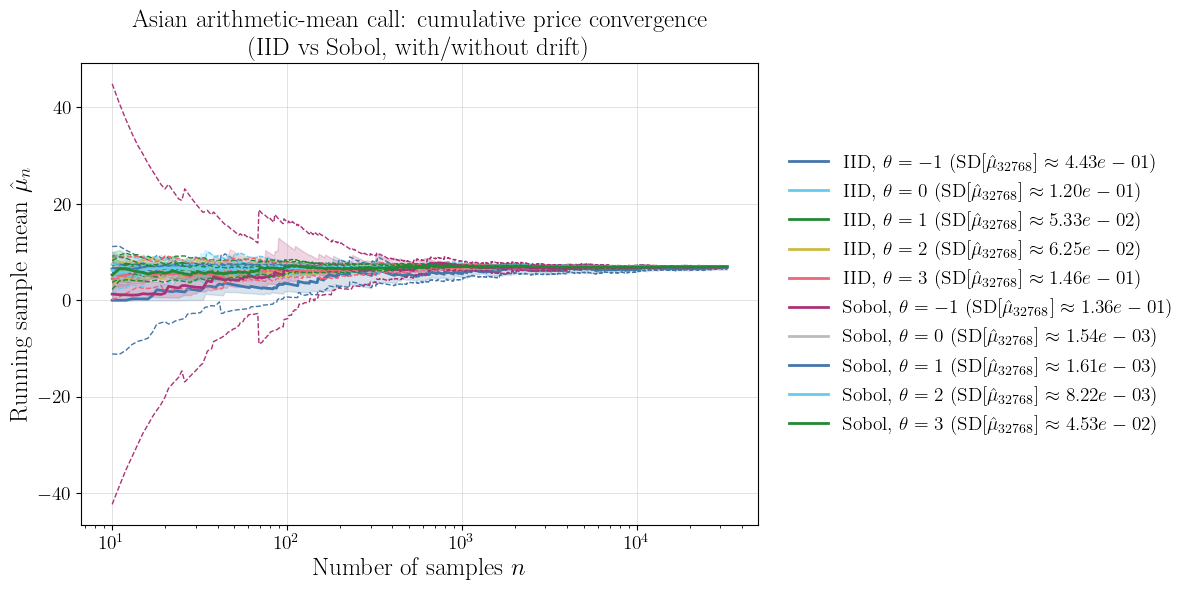

In [9]:
from classlib.plots import plot_middle_half_sample_mean, plot_multiple_middle_half_sample_means
n = 2**16
# samplers and labels
sampler_list = [
    ("IID", lambda n: np.random.random((n, d))),
    ("Sobol", lambda n: qp.Sobol(dimension=d, randomize=True).gen_samples(n)),
]
drift_list = [-1, 0, 1, 2, 3]  # constant drifts to test (0 = no importance sampling)

# --- Build configs dict (f returns per-path payoffs) ---
configs = {}
for s_name, sampler in sampler_list:
    for drift in drift_list:
        key = f"{s_name}, theta={drift:g}"
        label = rf"{s_name}, $\theta={drift:g}$"
        configs[key] = {
            "sampler": sampler,
            "f": (lambda X, drift=drift: asian_arith_mean_call_payoff(X, S0, r, sigma, T, K, drift=None if drift == 0.0 else drift, A=A)),
            "label": label,
        }

# --- Plot; the function will: for each N and replicate, compute cumulative means and middle-half bands ---
ax, info = plot_multiple_middle_half_sample_means(
    configs,
    title="Asian arithmetic-mean call: cumulative price convergence\n(IID vs Sobol, with/without drift)",
)


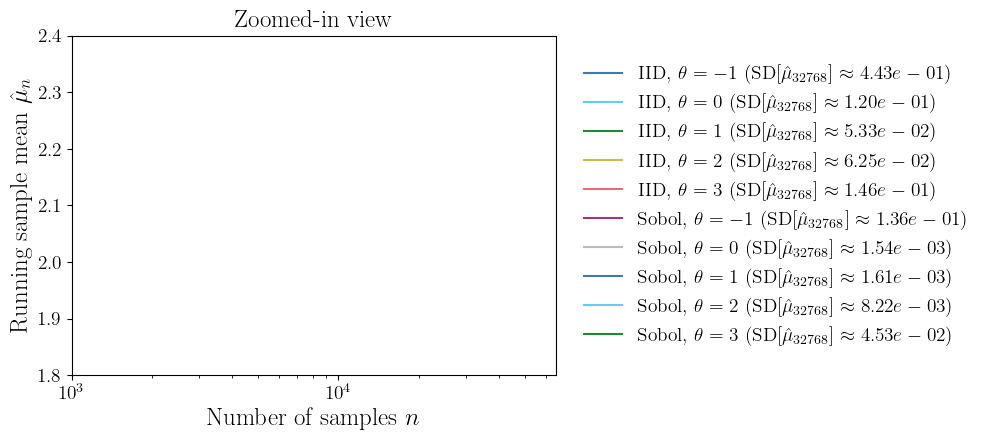

In [10]:
fig_zoom, ax_zoom = plt.subplots(figsize=(10, 4.5))

for key, data in info.items():
    n_vals = data["n"]
    med = data["median"]
    q25 = data["q25"]
    q75 = data["q75"]
    label = data.get("display_label", key)  # use stored display label
    color = data.get("color", None)         # use same color (optional)

    ax_zoom.fill_between(n_vals, q25, q75, alpha=0.20, color=color)
    ax_zoom.plot(n_vals, med, label=label, color=color)

ax_zoom.set_xscale("log", base=10)
ax_zoom.set_xlim(1000, n)
ax_zoom.set_ylim(1.8, 2.4)
ax_zoom.set_xlabel(r"Number of samples $n$")
ax_zoom.set_ylabel(r"Running sample mean $\hat{\mu}_n$")
ax_zoom.set_title("Zoomed-in view")
ax_zoom.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

fig_zoom.subplots_adjust(right=0.75)
fig_zoom.tight_layout()